# EnKF Data Assimilation
Sequential FARSITE simulation with Ensemble Kalman Filter data assimilation.

This notebook runs FARSITE forward simulations and incorporates actual observations through EnKF at each timestep.

In [1]:
import sys
sys.path.insert(0, 'src')

import pandas as pd
import geopandas as gpd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import requests
import time
from pyproj import Transformer
import contextily as ctx

from farsite import forward_pass_farsite, forward_pass_farsite_24h
from enkf import adjusted_state_EnKF_farsite
from geometry import geom_to_state, state_to_geom, align_states, plot_geometry
from config import OUTPUT_DIR, DATA_DIR, get_ensemble_size, DEFAULT_DIST_RES, DEFAULT_PERIM_RES, FIREMAP_WX_URL

from firemap import query_weather_for_timestep

## 1. Load Configuration and Data

In [2]:
# Load workflow configuration
with open(DATA_DIR / "workflow_config.json", 'r') as f:
    workflow_config = json.load(f)

FIRE_NAME = workflow_config["fire_name"]
LCP_PATH = workflow_config["lcp_path"]
IGNITION_DATE = pd.Timestamp(workflow_config["ignition_date"])
CONTAINMENT_DATE = pd.Timestamp(workflow_config["containment_date"])
N_PERIMETERS = workflow_config["n_perimeters"]
PERIMETERS_PATH = workflow_config["perimeters_path"]

# SYNTHETIC = workflow_config["synthetic"]

print(f"Fire: {FIRE_NAME}")
print(f"Duration: {IGNITION_DATE.date()} to {CONTAINMENT_DATE.date()}")
print(f"Number of perimeter updates: {N_PERIMETERS}")
print(f"Landscape file: {LCP_PATH}")
print(f"geojson path: {PERIMETERS_PATH}")
# print(f"Synthetic Fire?: {SYNTHETIC}")

Fire: Border 2 Synthetic
Duration: 2025-01-24 to 2025-01-25
Number of perimeter updates: 13
Landscape file: landscape.lcp
geojson path: /dtwinvol/tcaglar/wildfire-digital-twin/outputs/border_2_synthetic_perimeters.geojson


In [3]:
# Load perimeters — already sorted oldest→newest by fetch_fire_perimeters()
# perimeters_gdf = gpd.read_file(
#     OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_perimeters.geojson"
# )

with open(DATA_DIR / "workflow_config.json", 'r') as f:
    workflow_config = json.load(f)
PERIMETERS_PATH = workflow_config["perimeters_path"]

perimeters_gdf = gpd.read_file(PERIMETERS_PATH)

perimeters_gdf['datetime'] = pd.to_datetime(perimeters_gdf['datetime'])

print(f"Loaded {len(perimeters_gdf)} perimeters")
for i, row in perimeters_gdf.iterrows():
    print(f"  [{i}] {row['datetime']}  —  {row.geometry.area/1e6:.2f} km²")

Loaded 13 perimeters
  [0] 2025-01-24 13:00:00  —  0.04 km²
  [1] 2025-01-24 14:00:00  —  0.38 km²
  [2] 2025-01-24 15:00:00  —  0.94 km²
  [3] 2025-01-24 16:00:00  —  2.03 km²
  [4] 2025-01-24 17:00:00  —  3.49 km²
  [5] 2025-01-24 18:00:00  —  5.74 km²
  [6] 2025-01-24 19:00:00  —  9.00 km²
  [7] 2025-01-24 20:00:00  —  13.72 km²
  [8] 2025-01-24 21:00:00  —  21.99 km²
  [9] 2025-01-24 22:00:00  —  31.39 km²
  [10] 2025-01-24 23:00:00  —  39.84 km²
  [11] 2025-01-25 00:00:00  —  49.62 km²
  [12] 2025-01-25 01:00:00  —  55.94 km²


In [4]:
# Load weather location from config
wx_lat = workflow_config["weather_location"]["lat"]
wx_lon = workflow_config["weather_location"]["lon"]

print(f"\nWeather query location: {wx_lat:.4f}, {wx_lon:.4f}")
print("Weather will be queried dynamically for each timestep")


Weather query location: 32.5959, -116.8571
Weather will be queried dynamically for each timestep


## 2. Configure Simulation Parameters

In [5]:
# FARSITE parameters
DIST_RES = DEFAULT_DIST_RES  # meters
PERIM_RES = DEFAULT_PERIM_RES  # meters
FARSITE_TIMESTEP = pd.Timedelta(minutes=30)

# EnKF parameters
VSIZE = 300  # Observation noise (meters)
WSIZE = 100  # Model noise (meters)
RANDOM_SEED = 1234

# Initialize random number generator
rng = np.random.Generator(np.random.PCG64(RANDOM_SEED))

print("Simulation Parameters:")
print(f"  FARSITE distance resolution: {DIST_RES} m")
print(f"  FARSITE perimeter resolution: {PERIM_RES} m")
print(f"  FARSITE timestep: {FARSITE_TIMESTEP}")
print(f"  Observation noise (vsize): {VSIZE} m")
print(f"  Model noise (wsize): {WSIZE} m")

Simulation Parameters:
  FARSITE distance resolution: 150 m
  FARSITE perimeter resolution: 150 m
  FARSITE timestep: 0 days 00:30:00
  Observation noise (vsize): 300 m
  Model noise (wsize): 100 m


## 3. Initialize Tracking Variables

In [6]:
# Storage for results
results = {
    'timestep': [],
    'datetime': [],
    'initial_geom': [],
    'observed_geom': [],
    'predicted_geom': [],
    'analysis_geom': [],
    'covariance': [],
    'n_vertices': [],
    'ensemble_size': [],
    'valid_ensemble_members': [],
    'mean_wind_speed': [],      # NEW: Track wind speed
    'mean_wind_direction': [],  # NEW: Track wind direction
    'n_weather_obs': []          # NEW: Number of weather observations
}

# Initialize state for first timestep
current_state = geom_to_state(perimeters_gdf['geometry'].iloc[0])
# n_vertex = current_state.shape[0] // 2
n_vertex = 20
X = 1000.0 * np.eye(2 * n_vertex)  # Initial covariance

print(f"Initial state:")
print(f"  Vertices: {n_vertex}")
print(f"  State dimension: {2 * n_vertex}")
print(f"  Covariance shape: {X.shape}")

Initial state:
  Vertices: 20
  State dimension: 40
  Covariance shape: (40, 40)


## 4. Sequential Simulation Loop

**FARSITE → EnKF Feedback Loop:**

Note: this loop can take 1+ hours to complete, depending on lengths and amounts of timesteps.

For each timestep (t → t+1):
1. **FARSITE Prediction**: Use current state (from previous EnKF analysis) as initial condition
2. **EnKF Assimilation**: Combine FARSITE prediction with actual observation
3. **Feedback**: EnKF analysis becomes the initial condition for next timestep

This creates a feedback loop where observations continuously correct the predictions.

#### Test FARSITE RUN file removals

In [7]:
# from farsite import Farsite

# poly = initial_geom
# new_params = farsite_params
# lcppath = LCP_PATH
# start_time = current_time

# farsite = Farsite(
#     poly, new_params,
#     start_time=start_time,
#     lcppath=lcppath
# )

In [8]:
# farsite.run()

In [9]:
# out = farsite.output_geom()

#### Test weather

In [10]:
wind_speed, wind_direction = query_weather_for_timestep(wx_lat, wx_lon, IGNITION_DATE, CONTAINMENT_DATE, verbose=True)

  Querying weather: 2025-01-24 13:00:00 to 2025-01-25 01:00:00
  Retrieved 59 observations
  Wind: 5.0 mph @ 131°


#### Main simulation loop

In [ ]:
# Main simulation loop
n_timesteps = len(perimeters_gdf) - 1  # We predict from t to t+1

print(f"Starting sequential simulation for {n_timesteps} timesteps...\n")
print("="*80)

for t in range(n_timesteps):
    print(f"\n{'='*80}")
    print(f"TIMESTEP {t} → {t+1}")
    print(f"{'='*80}")
    
    # Get current and next observation
    current_obs = perimeters_gdf.iloc[t]
    next_obs = perimeters_gdf.iloc[t + 1]
    
    current_time = pd.Timestamp(current_obs['datetime'])
    next_time = pd.Timestamp(next_obs['datetime'])
    dt = next_time - current_time
    
    print(f"Current time: {current_time}")
    print(f"Next time: {next_time}")
    print(f"Time delta: {dt}")
    
    # Geometries
    initial_geom = state_to_geom(current_state)
    observed_geom = next_obs['geometry']
    
    print(f"\nInitial perimeter area: {initial_geom.area / 1e6:.2f} km²")
    print(f"Observed perimeter area: {observed_geom.area / 1e6:.2f} km²")
    
    # ========================================================================
    # STEP 1: FARSITE Forward Prediction
    # ========================================================================
    print(f"\n[1/2] Running FARSITE forward prediction...")
    
    # Query weather for this specific timestep
    try:
        timestep_ws_list, timestep_wd_list = query_weather_for_timestep(
            lat=wx_lat,
            lon=wx_lon,
            start_time=current_time,
            end_time=next_time,
            verbose=True
        )
        mean_ws = np.mean(timestep_ws_list)
        mean_wd = np.mean(timestep_wd_list)

    except Exception as e:
        print(f"  Using fallback weather: {e}")
        mean_ws = 10.0
        mean_wd = 225.0
    
    # ======================================================
    # ========== 12h Prediction for comparison =============
    # ======================================================

    farsite_params = {
        'windspeed': int(mean_ws),
        'winddirection': int(mean_wd),
        'dt': pd.Timedelta(minutes=30)
    }
    
    predicted_geom = initial_geom
    for i in tqdm(range(24 - t), desc='Calculating 12h prediction...'):
        predicted_geom = forward_pass_farsite(
            poly=predicted_geom,
            params=farsite_params,
            start_time=current_time.strftime("%Y-%m-%d %H:%M:%S"),
            lcppath=LCP_PATH,
            dist_res=DIST_RES,
            perim_res=PERIM_RES
        )
    
    if predicted_geom is None:
        print(f"WARNING: FARSITE failed at timestep {t}. Skipping to next.")
        continue
    
    print(f"✓ FARSITE prediction complete")
    print(f"  Predicted perimeter area: {predicted_geom.area / 1e6:.2f} km²")
    
    # ========================================================================
    # STEP 2: EnKF Data Assimilation
    # ========================================================================
    print(f"\n[2/2] Running EnKF data assimilation...")
    
    # Prepare states
    observation_state = geom_to_state(observed_geom)
    
    # Align states to ensure consistent vertex count
    # n_vertex = n
    observation_state, current_state = align_states(
        [observation_state, current_state],
        vertex_count=n_vertex
    )
    
    # EnKF configuration
    n_states = 2 * n_vertex
    n_output = n_states
    n_samples = get_ensemble_size(n_vertex)
    
    print(f"  State dimension: {n_states}")
    print(f"  Ensemble size: {n_samples}")
    
    # Sample weather for ensemble from timestep-specific data
    if len(timestep_ws_list) > 1:
        idx = rng.integers(0, len(timestep_ws_list), size=n_samples)
        sampled_wslst = np.asarray(timestep_ws_list)[idx]
        sampled_wdlst = np.asarray(timestep_wd_list)[idx]
    else:
        # If only one observation, add noise around it
        sampled_wslst = mean_ws + rng.normal(0, 2.0, size=n_samples)  # +/- 2 mph
        sampled_wdlst = mean_wd + rng.normal(0, 15.0, size=n_samples)  # +/- 15 degrees
        sampled_wslst = np.maximum(sampled_wslst, 0)  # Wind speed can't be negative
        sampled_wdlst = np.fmod(sampled_wdlst + 360, 360)  # Keep in [0, 360)
    
    # Run EnKF
    try: # Important params: 
        adjusted_state, X, zkphat, xkhat, ykhat, xkphat = adjusted_state_EnKF_farsite(
            initial_state=current_state,
            observation_state=observation_state,
            observation_time=next_time,
            X=X,
            n_states=n_states,
            n_output=n_output,
            n_vertex=n_vertex,
            n_samples=n_samples,
            rng=rng,
            sampled_wslst=sampled_wslst,
            sampled_wdlst=sampled_wdlst,
            dt=FARSITE_TIMESTEP,
            vsize=VSIZE,
            wsize=WSIZE,
            dist_res=DIST_RES,
            perim_res=PERIM_RES,
            lcppath=LCP_PATH
        )
        
        analysis_geom = state_to_geom(adjusted_state)
        
        # Count valid ensemble members (non-zero forecasts)
        valid_members = np.sum(np.any(zkphat != 0, axis=0))
        
        print(f"✓ EnKF complete")
        print(f"  Valid ensemble members: {valid_members}/{n_samples}")
        print(f"  Analysis perimeter area: {analysis_geom.area / 1e6:.2f} km²")
        
    except Exception as e:
        print(f"ERROR in EnKF at timestep {t}: {e}")
        analysis_geom = observed_geom  # Fallback to observation
        adjusted_state = observation_state
        valid_members = 0
    
    # ========================================================================
    # STEP 3: Store Results
    # ========================================================================
    results['timestep'].append(t)
    results['datetime'].append(next_time)
    results['initial_geom'].append(initial_geom)
    results['observed_geom'].append(observed_geom)
    results['predicted_geom'].append(predicted_geom)
    results['analysis_geom'].append(analysis_geom)
    results['covariance'].append(X.copy())
    results['n_vertices'].append(n_vertex)
    results['ensemble_size'].append(n_samples)
    results['valid_ensemble_members'].append(valid_members)
    
    results['mean_wind_speed'].append(mean_ws)
    results['mean_wind_direction'].append(mean_wd)
    results['n_weather_obs'].append(len(timestep_ws_list))

    # Save the results into a pickle file for checkpoint
    pd.to_pickle(results, OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_enkf_results.pkl")
    
        # Update state for next iteration (use analysis as new initial condition)
    current_state = adjusted_state
    
    print(f"\n✓ Timestep {t} → {t+1} complete")

print(f"\n{'='*80}")
print(f"SIMULATION COMPLETE")
print(f"{'='*80}")
print(f"\nProcessed {len(results['timestep'])} timesteps successfully")

Starting sequential simulation for 12 timesteps...


TIMESTEP 0 → 1
Current time: 2025-01-24 13:00:00
Next time: 2025-01-24 14:00:00
Time delta: 0 days 01:00:00

Initial perimeter area: 0.04 km²
Observed perimeter area: 0.38 km²

[1/2] Running FARSITE forward prediction...
  Querying weather: 2025-01-24 13:00:00 to 2025-01-24 14:00:00
  Retrieved 7 observations
  Wind: 8.8 mph @ 87°


Calculating 12h prediction...:  46%|████▌     | 11/24 [03:42<04:33, 21.04s/it]

In [12]:
results = pd.read_pickle(OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_sequential_results_v100.pkl")

## 5. Visualize Results

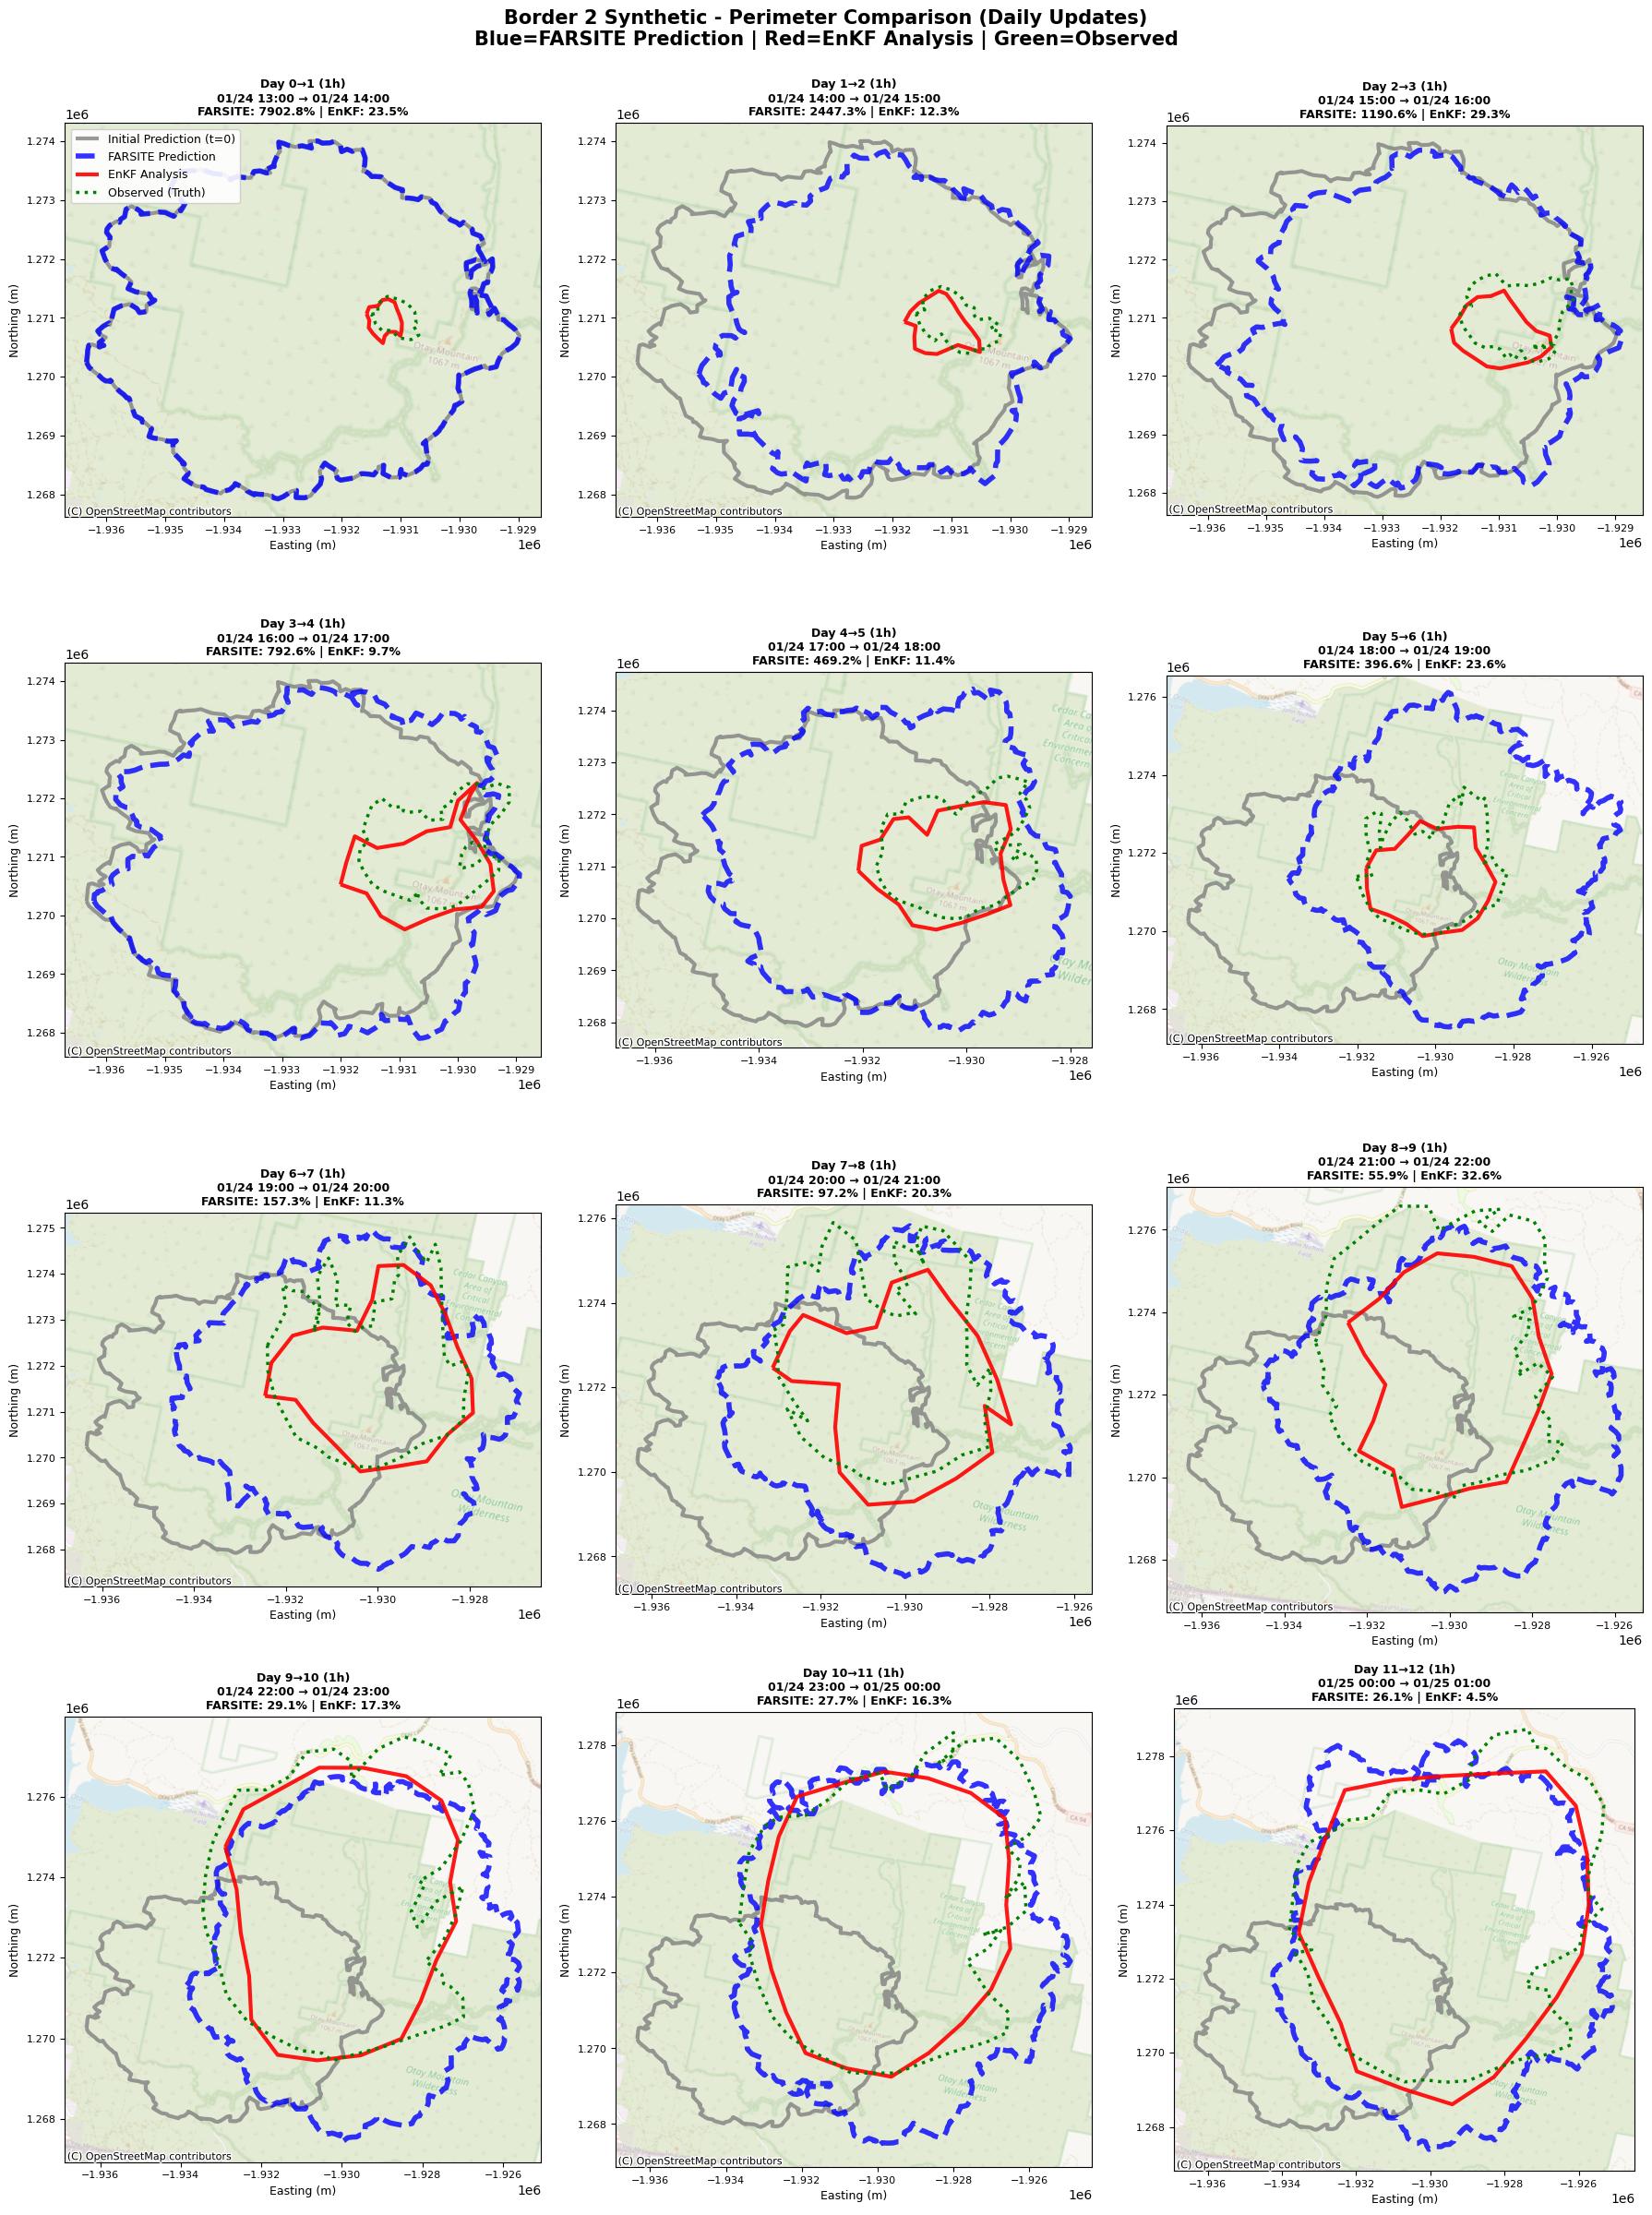


Fire Area and Error Summary
Timestep | Observed | FARSITE  | EnKF     | FARSITE Err | EnKF Err
──────────────────────────────────────────────────────────────────────
  0→1    |   0.38   |  30.05   |   0.29   | 7902.8%     |   23.5%
  1→2    |   0.94   |  23.95   |   0.82   | 2447.3%     |   12.3%
  2→3    |   2.03   |  26.26   |   1.44   | 1190.6%     |   29.3%
  3→4    |   3.49   |  31.19   |   3.15   |  792.6%     |    9.7%
  4→5    |   5.74   |  32.70   |   5.09   |  469.2%     |   11.4%
  5→6    |   9.00   |  44.70   |   6.88   |  396.6%     |   23.6%
  6→7    |  13.72   |  35.29   |  12.16   |  157.3%     |   11.3%
  7→8    |  21.99   |  43.36   |  17.52   |   97.2%     |   20.3%
  8→9    |  31.39   |  48.95   |  21.17   |   55.9%     |   32.6%
  9→10    |  39.84   |  51.43   |  32.93   |   29.1%     |   17.3%
  10→11    |  49.62   |  63.38   |  41.53   |   27.7%     |   16.3%
  11→12    |  55.94   |  70.53   |  53.41   |   26.1%     |    4.5%


In [13]:
# Map visualization: Compare perimeters at each timestep
import contextily as ctx

n_timesteps = len(results['timestep'])
n_cols = 3
n_rows = (n_timesteps + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_timesteps > 1 else [axes]

for idx, t in enumerate(results['timestep']):
    ax = axes[idx]
    
    # Create GeoDataFrames for plotting
    noda_gdf = gpd.GeoDataFrame([1], geometry=[results['predicted_geom'][0]], crs="EPSG:5070")
    pred_gdf = gpd.GeoDataFrame([1], geometry=[results['predicted_geom'][idx]], crs="EPSG:5070")
    analysis_gdf = gpd.GeoDataFrame([1], geometry=[results['analysis_geom'][idx]], crs="EPSG:5070")
    obs_gdf = gpd.GeoDataFrame([1], geometry=[results['observed_geom'][idx]], crs="EPSG:5070")
    
    # Plot in order: FARSITE → EnKF → Observed
    noda_gdf.boundary.plot(ax=ax, color='gray', linewidth=3, linestyle='-', 
                          label='Initial Prediction (t=0)', zorder=2, alpha=0.8)
    pred_gdf.boundary.plot(ax=ax, color='blue', linewidth=4, linestyle='--', 
                          label='FARSITE Prediction', zorder=2, alpha=0.8)
    analysis_gdf.boundary.plot(ax=ax, color='red', linewidth=3, linestyle='-', 
                              label='EnKF Analysis', zorder=3, alpha=0.9)
    obs_gdf.boundary.plot(ax=ax, color='green', linewidth=2.5, linestyle=':', 
                         label='Observed (Truth)', zorder=4)
    
# ((np.float64(-1936202.4869219281), np.float64(-1925455.7746395073)),
#  (np.float64(1268760.155659983), np.float64(1279111.2710736948)))
    # ax.set_xlim(-1950202.4869219281, -1925455.7746395073)
    # ax.set_ylim(1264760.155659983, 1279111.2710736948)

    # Add basemap with explicit zoom level
    try:
        ctx.add_basemap(
            ax=ax, 
            source=ctx.providers.OpenStreetMap.Mapnik, 
            crs="EPSG:5070",
            alpha=0.5,
            zorder=1
        )
    except Exception as e:
        print(f"Could not add basemap for timestep {t}: {e}")
    
    # Format
    ax.set_aspect('equal')
    
    # Get start and end dates
    start_date = perimeters_gdf.iloc[t]['datetime']
    end_date = results["datetime"][idx]
    time_diff = (end_date - start_date).total_seconds() / 3600
    
    # Calculate error statistics
    obs_area = results['observed_geom'][idx].area / 1e6
    pred_area = results['predicted_geom'][idx].area / 1e6
    enkf_area = results['analysis_geom'][idx].area / 1e6
    farsite_err = abs(pred_area - obs_area) / obs_area * 100
    enkf_err = abs(enkf_area - obs_area) / obs_area * 100
    
    ax.set_title(
        f'Day {t}→{t+1} ({time_diff:.0f}h)\n' +
        f'{start_date.strftime("%m/%d %H:%M")} → {end_date.strftime("%m/%d %H:%M")}\n' +
        f'FARSITE: {farsite_err:.1f}% | EnKF: {enkf_err:.1f}%',
        fontsize=9, weight='bold'
    )
    
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_ylabel('Northing (m)', fontsize=9)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for idx in range(n_timesteps, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{FIRE_NAME} - Perimeter Comparison (Daily Updates)\n' +
            'Blue=FARSITE Prediction | Red=EnKF Analysis | Green=Observed', 
            fontsize=15, weight='bold', y=0.998)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_perimeter_maps.png", 
           dpi=200, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n{'='*70}")
print(f"Fire Area and Error Summary")
print(f"{'='*70}")
print(f"Timestep | Observed | FARSITE  | EnKF     | FARSITE Err | EnKF Err")
print(f"{'─'*70}")
for idx, t in enumerate(results['timestep']):
    obs_area = results['observed_geom'][idx].area / 1e6
    pred_area = results['predicted_geom'][idx].area / 1e6
    enkf_area = results['analysis_geom'][idx].area / 1e6
    farsite_err = abs(pred_area - obs_area) / obs_area * 100
    enkf_err = abs(enkf_area - obs_area) / obs_area * 100
    print(f"  {t}→{t+1}    | {obs_area:6.2f}   | {pred_area:6.2f}   | {enkf_area:6.2f}   | "
          f"{farsite_err:6.1f}%     | {enkf_err:6.1f}%")
print(f"{'='*70}")

In [14]:
results['covariance'][-1]

array([[ 87405.64436219, -38529.91554262,  68319.15152208, ...,
        -89136.12570711,  43598.18618983, -83488.81258156],
       [-38529.91554262,  26213.50818966, -33019.95669516, ...,
         45895.90779611, -21122.33294356,  43284.3692512 ],
       [ 68319.15152208, -33019.95669516,  64660.46778542, ...,
        -74165.21348946,  35556.60909455, -69004.10910032],
       ...,
       [-89136.12570711,  45895.90779611, -74165.21348946, ...,
        102210.69063185, -46970.86108103,  93661.74853644],
       [ 43598.18618983, -21122.33294356,  35556.60909455, ...,
        -46970.86108103,  26170.83525349, -43110.89264115],
       [-83488.81258156,  43284.3692512 , -69004.10910032, ...,
         93661.74853644, -43110.89264115,  89191.3625132 ]],
      shape=(40, 40))

In [15]:
axes[0].get_xlim(), axes[0].get_ylim()

((np.float64(-1936707.05), np.float64(-1928609.95)),
 (np.float64(1267618.85), np.float64(1274310.15)))

## 6. Save Results

In [16]:
# Create results GeoDataFrame
results_gdf = gpd.GeoDataFrame({
    'timestep': results['timestep'],
    'datetime': results['datetime'],
    'type': ['analysis'] * len(results['timestep']),
    'geometry': results['analysis_geom'],
    'area_km2': [g.area / 1e6 for g in results['analysis_geom']],
    'n_vertices': results['n_vertices'],
    'ensemble_size': results['ensemble_size'],
    'valid_members': results['valid_ensemble_members']
}, crs="EPSG:5070")

# Save analysis results
output_path = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_sequential_analysis.geojson"
results_gdf.to_file(output_path, driver="GeoJSON")
print(f"✓ Analysis results saved to {output_path}")

✓ Analysis results saved to /dtwinvol/tcaglar/wildfire-digital-twin/outputs/border_2_synthetic_sequential_analysis.geojson


In [ ]:
pd.to_pickle(results, OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_sequential_results_v{VSIZE}.pkl")

In [21]:
# Save final state for potential continuation
from enkf import save_enkf_state

if len(results['timestep']) > 0:
    final_state_path = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_final_state.npz"
    save_enkf_state(
        final_state_path,
        current_state,
        current_state,  # Use current as both initial and adjusted
        X,
        zkphat if 'zkphat' in locals() else np.array([]),
        xkhat if 'xkhat' in locals() else np.array([]),
        ykhat if 'ykhat' in locals() else np.array([]),
        xkphat if 'xkphat' in locals() else np.array([]),
        rng
    )
    print(f"✓ Final state saved to {final_state_path}")

EnKF state saved to /dtwinvol/tcaglar/wildfire-digital-twin/outputs/border_2_synthetic_final_state.npz
✓ Final state saved to /dtwinvol/tcaglar/wildfire-digital-twin/outputs/border_2_synthetic_final_state.npz


In [22]:
# Summary statistics
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)
print(f"\nFire: {FIRE_NAME}")
print(f"Timesteps processed: {len(results['timestep'])}")
print(f"\nArea evolution:")
print(f"  Initial: {results['initial_geom'][0].area / 1e6:.2f} km²")
print(f"  Final (observed): {results['observed_geom'][-1].area / 1e6:.2f} km²")
print(f"  Final (FARSITE prediction): {results['predicted_geom'][-1].area / 1e6:.2f} km²")
print(f"  Final (EnKF analysis): {results['analysis_geom'][-1].area / 1e6:.2f} km²")
print(f"\nEnsemble performance:")
# print(f"  Mean success rate: {np.mean(success_rate):.1f}%")
print(f"  Mean ensemble size: {np.mean(results['ensemble_size']):.0f}")
print(f"\nOutput files:")
print(f"  - {output_path.name}")
print(f"  - {final_state_path.name}")
print(f"  - Area evolution plot")
print(f"  - Spatial evolution plot")
print(f"  - Ensemble statistics plot")


ANALYSIS SUMMARY

Fire: Border 2 Synthetic
Timesteps processed: 12

Area evolution:
  Initial: 0.04 km²
  Final (observed): 55.94 km²
  Final (FARSITE prediction): 70.53 km²
  Final (EnKF analysis): 53.41 km²

Ensemble performance:
  Mean ensemble size: 300

Output files:
  - border_2_synthetic_sequential_analysis.geojson
  - border_2_synthetic_final_state.npz
  - Area evolution plot
  - Spatial evolution plot
  - Ensemble statistics plot
